# **Importing Libraries**

In [1]:
import os
import pandas as pd
import numpy as np
import joblib
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
import shap
warnings.filterwarnings('ignore')

from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.linear_model import LogisticRegression
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.metrics import brier_score_loss, matthews_corrcoef, log_loss
from scipy.stats import ks_2samp
from sklearn.metrics import (roc_auc_score, roc_curve, precision_recall_curve, auc, confusion_matrix, classification_report)

# **Loading Processed Data**

In [2]:
print("--- Loading Processed Data ---")
data_dir = "MSME_Processed_Data"

X_train = pd.read_csv(os.path.join(data_dir, 'X_train_ready.csv'))
y_train = pd.read_csv(os.path.join(data_dir, 'y_train_ready.csv')).squeeze()

X_val = pd.read_csv(os.path.join(data_dir, 'X_val_ready.csv'))
y_val = pd.read_csv(os.path.join(data_dir, 'y_val_ready.csv')).squeeze()

X_test = pd.read_csv(os.path.join(data_dir, 'X_test_ready.csv'))
y_test = pd.read_csv(os.path.join(data_dir, 'y_test_ready.csv')).squeeze()

print(f"Training set: {X_train.shape} | Validation set: {X_val.shape} | Test set: {X_test.shape}")

--- Loading Processed Data ---
Training set: (2242, 174) | Validation set: (256, 174) | Test set: (257, 174)


In [3]:
# Calculate the imbalance ratio for XGBoost
# Since we used SMOTETomek, X_train is relatively balanced, but setting scale_pos_weight 
# acts as a secondary safety net.
imbalance_ratio = (y_train == 0).sum() / (y_train == 1).sum() if (y_train == 1).sum() > 0 else 1

# **Train Baseline : Logistic Regression**

In [4]:
print("--- Training Logistic Regression (Baseline) ---")
# Logistic Regression is the banking industry standard baseline
logreg_model = LogisticRegression(max_iter=1000, random_state=42)
logreg_model.fit(X_train, y_train)
print("Logistic Regression training complete.")

--- Training Logistic Regression (Baseline) ---
Logistic Regression training complete.


# **Train Balanced Random Forest**

In [5]:
print("\n--- Training Balanced Random Forest (Bagging Ensemble) ---")
# Balanced Random Forest handles minority classes by undersampling inside the bootstrap
rf_model = BalancedRandomForestClassifier(n_estimators=500, max_depth=6, random_state=42)
rf_model.fit(X_train, y_train)
print("Balanced Random Forest training complete.")


--- Training Balanced Random Forest (Bagging Ensemble) ---
Balanced Random Forest training complete.


# **Train XGBoost with Early Stopping**

In [6]:
print("\n--- Training XGBoost Classifier ---")
xgb_model = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.01,       # Lowered from 0.05
    max_depth=4,              # Lowered from 6 to prevent memorizing
    reg_lambda=10,            # Added strong L2 Regularization
    eval_metric='auc',
    early_stopping_rounds=100,# Give it more patience before stopping
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

print(f"XGBoost stopped at tree {xgb_model.best_iteration}")


--- Training XGBoost Classifier ---
XGBoost stopped at tree 19


# **Train CatBoost with Early Stopping**

In [7]:
print("\n--- Training CatBoost Classifier ---")
cat_model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.01,       # Lowered from 0.05
    depth=4,                  # Lowered from 6
    l2_leaf_reg=10,           # Added strong L2 Regularization
    auto_class_weights=None,  # Removed because SMOTE already balanced it
    eval_metric='AUC',
    random_seed=42,
    verbose=False
)

cat_model.fit(
    X_train, y_train,
    eval_set=(X_val, y_val),
    early_stopping_rounds=50
)
print(f"CatBoost stopped at tree {cat_model.get_best_iteration()}")


--- Training CatBoost Classifier ---
CatBoost stopped at tree 10


# **Evaluate on the Unseen Test Set**

In [8]:
print("\n--- Evaluating All Models on Test Set ---")

# 1. Get prediction probabilities for the positive class (Default)
logreg_probs = logreg_model.predict_proba(X_test)[:, 1]
rf_probs = rf_model.predict_proba(X_test)[:, 1]
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]
cat_probs = cat_model.predict_proba(X_test)[:, 1]

# 2. Calculate ROC-AUC
logreg_auc = roc_auc_score(y_test, logreg_probs)
rf_auc = roc_auc_score(y_test, rf_probs)
xgb_auc = roc_auc_score(y_test, xgb_probs)
cat_auc = roc_auc_score(y_test, cat_probs)

# 3. Calculate Precision-Recall AUC
logreg_pr_auc = auc(*precision_recall_curve(y_test, logreg_probs)[:2][::-1])
rf_pr_auc = auc(*precision_recall_curve(y_test, rf_probs)[:2][::-1])
xgb_pr_auc = auc(*precision_recall_curve(y_test, xgb_probs)[:2][::-1])
cat_pr_auc = auc(*precision_recall_curve(y_test, cat_probs)[:2][::-1])

print(f"Logistic Regression - ROC-AUC: {logreg_auc:.4f} | PR-AUC: {logreg_pr_auc:.4f}")
print(f"Balanced RF         - ROC-AUC: {rf_auc:.4f} | PR-AUC: {rf_pr_auc:.4f}")
print(f"XGBoost             - ROC-AUC: {xgb_auc:.4f} | PR-AUC: {xgb_pr_auc:.4f}")
print(f"CatBoost            - ROC-AUC: {cat_auc:.4f} | PR-AUC: {cat_pr_auc:.4f}")


--- Evaluating All Models on Test Set ---
Logistic Regression - ROC-AUC: 0.6540 | PR-AUC: 0.2679
Balanced RF         - ROC-AUC: 0.7416 | PR-AUC: 0.1412
XGBoost             - ROC-AUC: 0.6843 | PR-AUC: 0.1245
CatBoost            - ROC-AUC: 0.7594 | PR-AUC: 0.1069


# **Plotting Graphs**

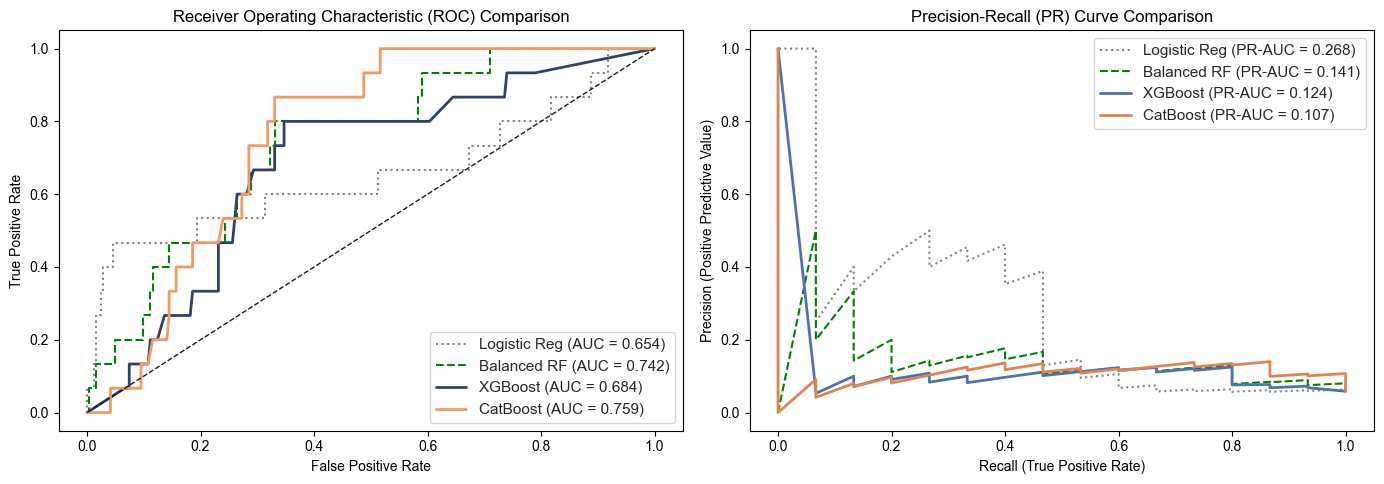

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.set_theme(style="whitegrid")

# Plot 1: ROC Curve for ALL 4 MODELS
logreg_fpr, logreg_tpr, _ = roc_curve(y_test, logreg_probs)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_probs)
cat_fpr, cat_tpr, _ = roc_curve(y_test, cat_probs)

axes[0].plot(logreg_fpr, logreg_tpr, label=f'Logistic Reg (AUC = {logreg_auc:.3f})', color='gray', linestyle=':')
axes[0].plot(rf_fpr, rf_tpr, label=f'Balanced RF (AUC = {rf_auc:.3f})', color='green', linestyle='--')
axes[0].plot(xgb_fpr, xgb_tpr, label=f'XGBoost (AUC = {xgb_auc:.3f})', color="#2E4365", lw=2)
axes[0].plot(cat_fpr, cat_tpr, label=f'CatBoost (AUC = {cat_auc:.3f})', color="#F39964", lw=2)

axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0].set_title('Receiver Operating Characteristic (ROC) Comparison', fontsize=12)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(loc='lower right')

# Plot 2: Precision-Recall Curve for ALL 4 MODELS
logreg_prec, logreg_rec, _ = precision_recall_curve(y_test, logreg_probs)
rf_prec, rf_rec, _ = precision_recall_curve(y_test, rf_probs)
xgb_prec, xgb_rec, _ = precision_recall_curve(y_test, xgb_probs)
cat_prec, cat_rec, _ = precision_recall_curve(y_test, cat_probs)

axes[1].plot(logreg_rec, logreg_prec, label=f'Logistic Reg (PR-AUC = {logreg_pr_auc:.3f})', color='gray', linestyle=':')
axes[1].plot(rf_rec, rf_prec, label=f'Balanced RF (PR-AUC = {rf_pr_auc:.3f})', color='green', linestyle='--')
axes[1].plot(xgb_rec, xgb_prec, label=f'XGBoost (PR-AUC = {xgb_pr_auc:.3f})', color='#4C72B0', lw=2)
axes[1].plot(cat_rec, cat_prec, label=f'CatBoost (PR-AUC = {cat_pr_auc:.3f})', color='#DD8452', lw=2)

axes[1].set_title('Precision-Recall (PR) Curve Comparison', fontsize=12)
axes[1].set_xlabel('Recall (True Positive Rate)')
axes[1].set_ylabel('Precision (Positive Predictive Value)')
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

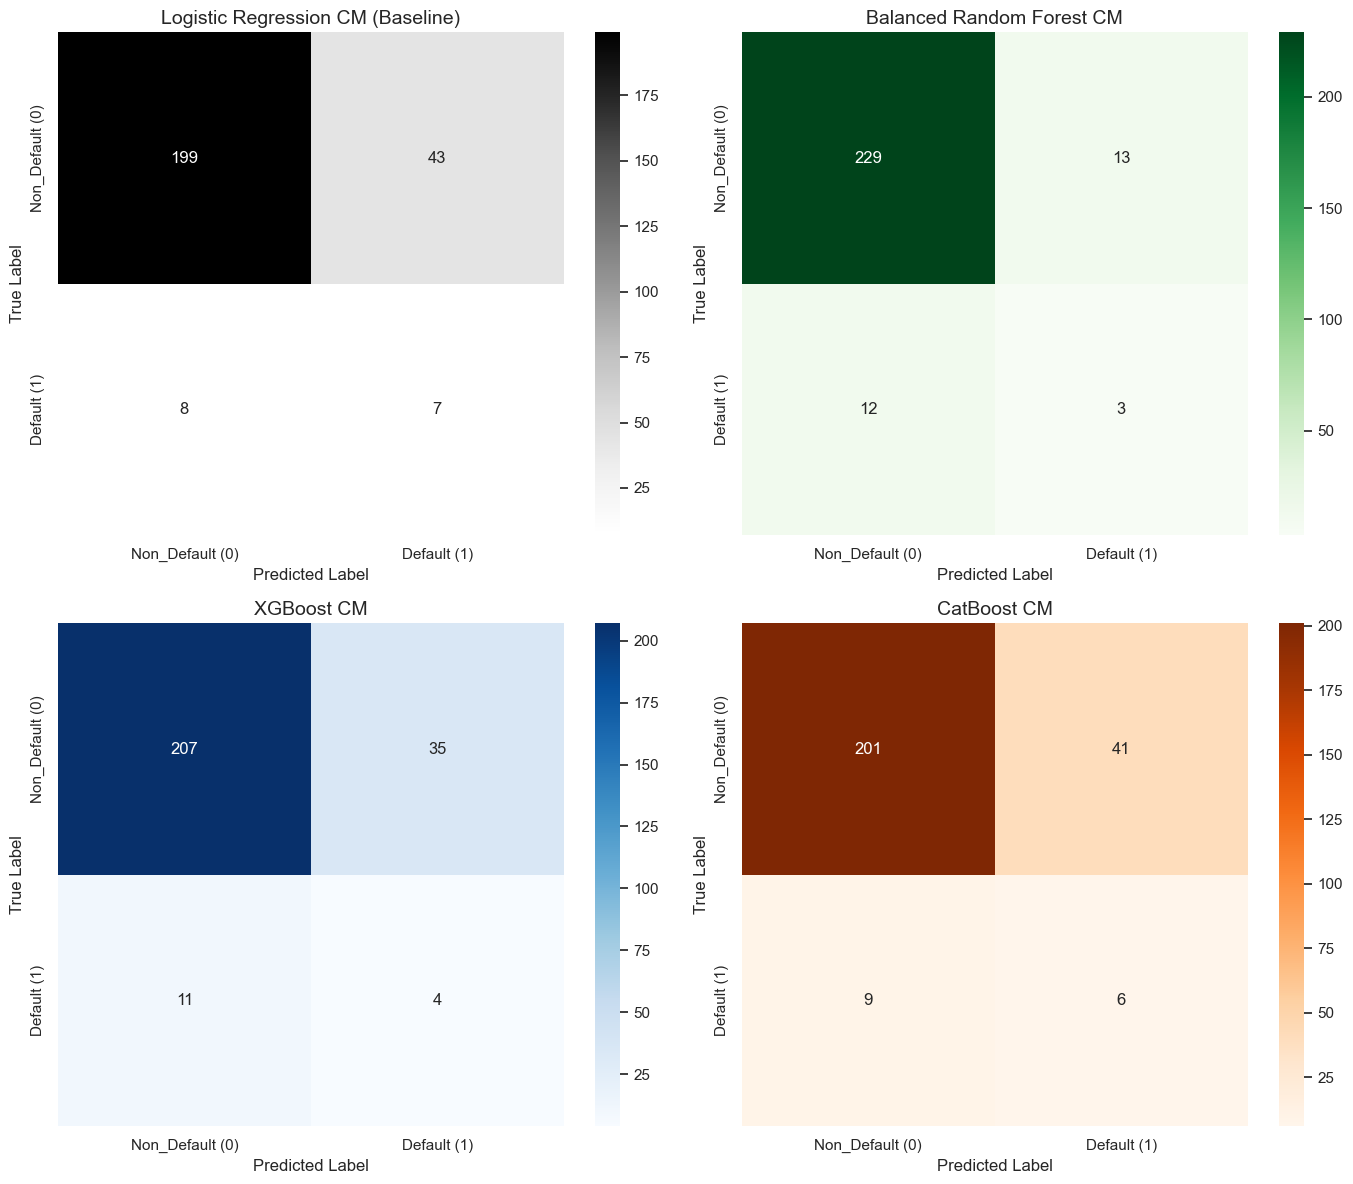

In [10]:
# --- GENERATE PREDICTIONS FOR ALL 4 MODELS ---
logreg_preds = logreg_model.predict(X_test)
rf_preds = rf_model.predict(X_test)
xgb_preds = xgb_model.predict(X_test)
cat_preds = cat_model.predict(X_test)

# --- PLOT CONFUSION MATRICES (2x2 Grid) ---
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
sns.set_theme(style="whitegrid")

def plot_cm(y_true, y_pred, ax, title, cmap):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax)
    ax.set_title(title, fontsize=14)
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')
    ax.set_xticklabels(['Non_Default (0)', 'Default (1)'])
    ax.set_yticklabels(['Non_Default (0)', 'Default (1)'])

# Plot all 4 matrices
plot_cm(y_test, logreg_preds, axes[0, 0], 'Logistic Regression CM (Baseline)', 'Greys')
plot_cm(y_test, rf_preds, axes[0, 1], 'Balanced Random Forest CM', 'Greens')
plot_cm(y_test, xgb_preds, axes[1, 0], 'XGBoost CM', 'Blues')
plot_cm(y_test, cat_preds, axes[1, 1], 'CatBoost CM', 'Oranges')

plt.tight_layout()
plt.show()



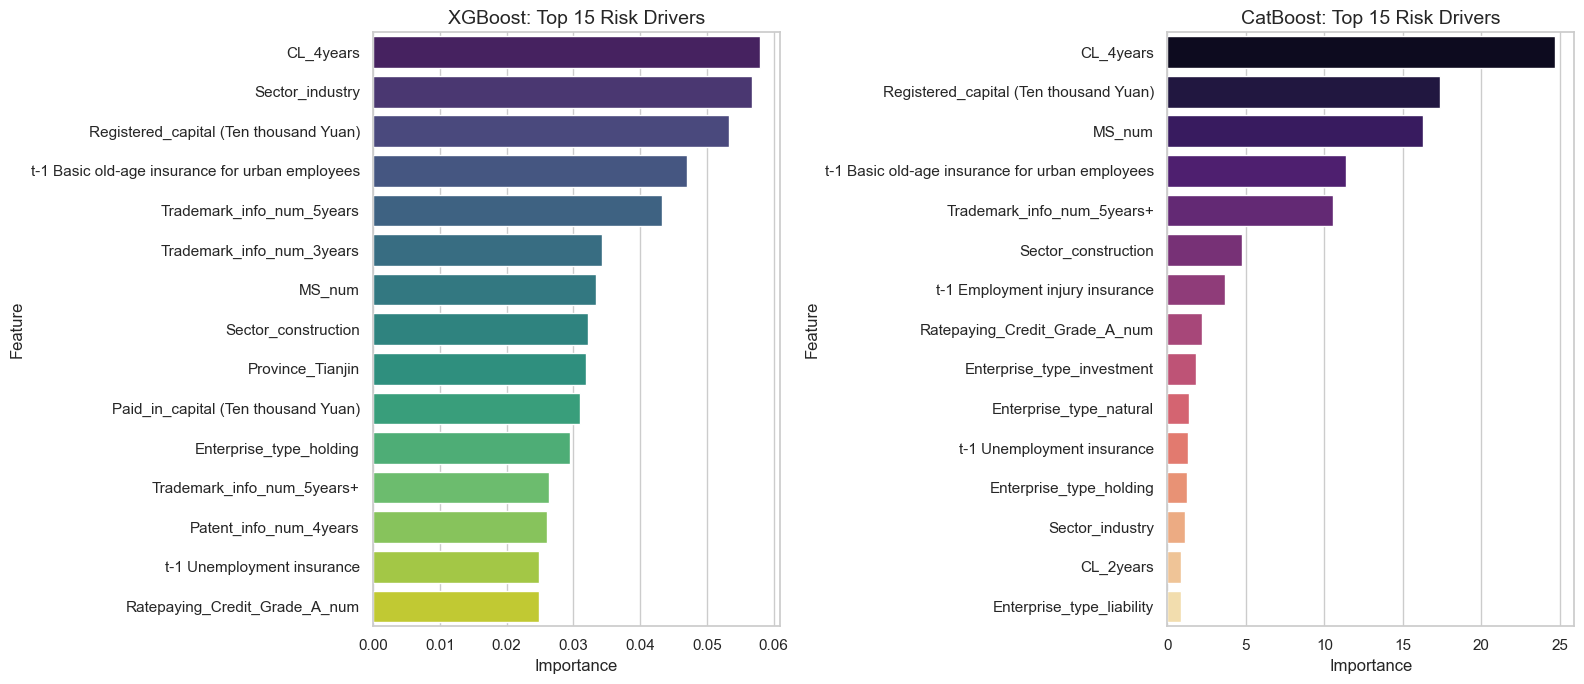

In [11]:
# --- FEATURE IMPORTANCE (For Boosting Models Only) ---
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Function to plot importance
def plot_importance(model, X, ax, title, color):
    importances = pd.DataFrame({
        'Feature': X.columns,
        'Importance': model.feature_importances_
    }).sort_values(by='Importance', ascending=False).head(15)
    
    sns.barplot(x='Importance', y='Feature', data=importances, palette=color, ax=ax)
    ax.set_title(title, fontsize=14)

# Plot XGBoost & CatBoost Importance
plot_importance(xgb_model, X_train, axes[0], 'XGBoost: Top 15 Risk Drivers', 'viridis')
plot_importance(cat_model, X_train, axes[1], 'CatBoost: Top 15 Risk Drivers', 'magma')

plt.tight_layout()
plt.show()

In [12]:
# --- DETAILED CLASSIFICATION REPORTS ---
print("\n" + "="*40)
print("1. LOGISTIC REGRESSION REPORT")
print("="*40)
print(classification_report(y_test, logreg_preds, target_names=['Non_Default (0)', 'Default (1)']))

print("\n" + "="*40)
print("2. BALANCED RANDOM FOREST REPORT")
print("="*40)
print(classification_report(y_test, rf_preds, target_names=['Non_Default (0)', 'Default (1)']))

print("\n" + "="*40)
print("3. XGBOOST CLASSIFICATION REPORT")
print("="*40)
print(classification_report(y_test, xgb_preds, target_names=['Non_Default (0)', 'Default (1)']))

print("\n" + "="*40)
print("4. CATBOOST CLASSIFICATION REPORT")
print("="*40)
print(classification_report(y_test, cat_preds, target_names=['Non_Default (0)', 'Default (1)']))


1. LOGISTIC REGRESSION REPORT
                 precision    recall  f1-score   support

Non_Default (0)       0.96      0.82      0.89       242
    Default (1)       0.14      0.47      0.22        15

       accuracy                           0.80       257
      macro avg       0.55      0.64      0.55       257
   weighted avg       0.91      0.80      0.85       257


2. BALANCED RANDOM FOREST REPORT
                 precision    recall  f1-score   support

Non_Default (0)       0.95      0.95      0.95       242
    Default (1)       0.19      0.20      0.19        15

       accuracy                           0.90       257
      macro avg       0.57      0.57      0.57       257
   weighted avg       0.91      0.90      0.90       257


3. XGBOOST CLASSIFICATION REPORT
                 precision    recall  f1-score   support

Non_Default (0)       0.95      0.86      0.90       242
    Default (1)       0.10      0.27      0.15        15

       accuracy                       

In [13]:
print("\n" + "="*50)
print("ADVANCED FINTECH EVALUATION METRICS SUMMARY")
print("="*50)

# 1. Define the KS helper function
def calculate_ks(y_true, y_probs):
    """Calculates the KS Statistic for Credit Risk (Max separation between classes)"""
    pos_probs = y_probs[y_true == 1]
    neg_probs = y_probs[y_true == 0]
    if len(pos_probs) == 0 or len(neg_probs) == 0:
        return 0
    ks_stat, _ = ks_2samp(pos_probs, neg_probs)
    return ks_stat

# 2. Package the models, predictions, and probabilities together
models_eval = {
    "Logistic Regression": (logreg_preds, logreg_probs, logreg_auc, logreg_pr_auc),
    "Balanced Random Forest": (rf_preds, rf_probs, rf_auc, rf_pr_auc),
    "XGBoost": (xgb_preds, xgb_probs, xgb_auc, xgb_pr_auc),
    "CatBoost": (cat_preds, cat_probs, cat_auc, cat_pr_auc)
}

# 3. Calculate all metrics and store them in a list
results_list = []
for name, (preds, probs, auc_val, pr_auc_val) in models_eval.items():
    ks_stat = calculate_ks(y_test, probs)
    mcc = matthews_corrcoef(y_test, preds)
    brier = brier_score_loss(y_test, probs)
    logloss = log_loss(y_test, probs)
    
    results_list.append({
        "Model": name,
        "ROC-AUC (↑)": round(auc_val, 4),
        "PR-AUC (↑)": round(pr_auc_val, 4),
        "KS Stat (↑)": round(ks_stat, 4),
        "MCC (↑)": round(mcc, 4),
        "Brier Score (↓)": round(brier, 4),
        "Log Loss (↓)": round(logloss, 4)
    })

# 4. Display as a clean, professional DataFrame
metrics_df = pd.DataFrame(results_list).set_index("Model")
display(metrics_df)

# (Optional) Save this table for your M.Tech report
metrics_df.to_csv("Advanced_Metrics_Comparison.csv")
print("\nMetrics table saved to 'Advanced_Metrics_Comparison.csv'")


ADVANCED FINTECH EVALUATION METRICS SUMMARY


,ROC-AUC (↑),PR-AUC (↑),KS Stat (↑),MCC (↑),Brier Score (↓),Log Loss (↓)
Model,,,,,,
Logistic Regression,0.6540,0.2679,0.4212,0.1711,0.1480,0.5928
Balanced Random Forest,0.7416,0.1412,0.4694,0.1419,0.1008,0.3492
XGBoost,0.6843,0.1245,0.4529,0.0797,0.2161,0.6250
CatBoost,0.7594,0.1069,0.5361,0.1398,0.2258,0.6445



Metrics table saved to 'Advanced_Metrics_Comparison.csv'


# **Saving Best Model**

In [14]:
# --- FINAL DYNAMIC SELECTION & SAVING ---
print("\n--- Final Selection & Saving ---")

# Ensure the saved_models directory exists
save_dir = "saved_models"
os.makedirs(save_dir, exist_ok=True)

# Create a dictionary to hold all models and their AUC scores
model_registry = {
    "Logistic_Regression": (logreg_model, logreg_auc),
    "Balanced_Random_Forest": (rf_model, rf_auc),
    "XGBoost": (xgb_model, xgb_auc),
    "CatBoost": (cat_model, cat_auc)
}

# Find the model with the absolute highest AUC score
best_name = max(model_registry, key=lambda k: model_registry[k][1])
best_model, best_auc = model_registry[best_name]

print(f"The Best Model is: {best_name.replace('_', ' ')} (Test AUC: {best_auc:.4f})")

model_path = os.path.join(save_dir, f"Best_MSME_Model_{best_name}.pkl")
joblib.dump(best_model, model_path)

print(f"Model successfully saved to: {model_path}")
print("This file can now be used for future MSME credit predictions!")


--- Final Selection & Saving ---
The Best Model is: CatBoost (Test AUC: 0.7594)
Model successfully saved to: saved_models/Best_MSME_Model_CatBoost.pkl
This file can now be used for future MSME credit predictions!


# **SHAP Explainability**

In [15]:
# Dynamically select the probabilities for the best model
if best_name == "CatBoost":
    best_probs = cat_probs
else:
    best_probs = xgb_probs

print(f'\n--- SHAP Explainability for {best_name} ---')
print(f'Computing SHAP values for {best_name}')

# Build the explainer around the winning model
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)
print(f'SHAP values computed: {X_test.shape[0]} companies x {X_test.shape[1]} features')



--- SHAP Explainability for CatBoost ---
Computing SHAP values for CatBoost
SHAP values computed: 257 companies x 174 features


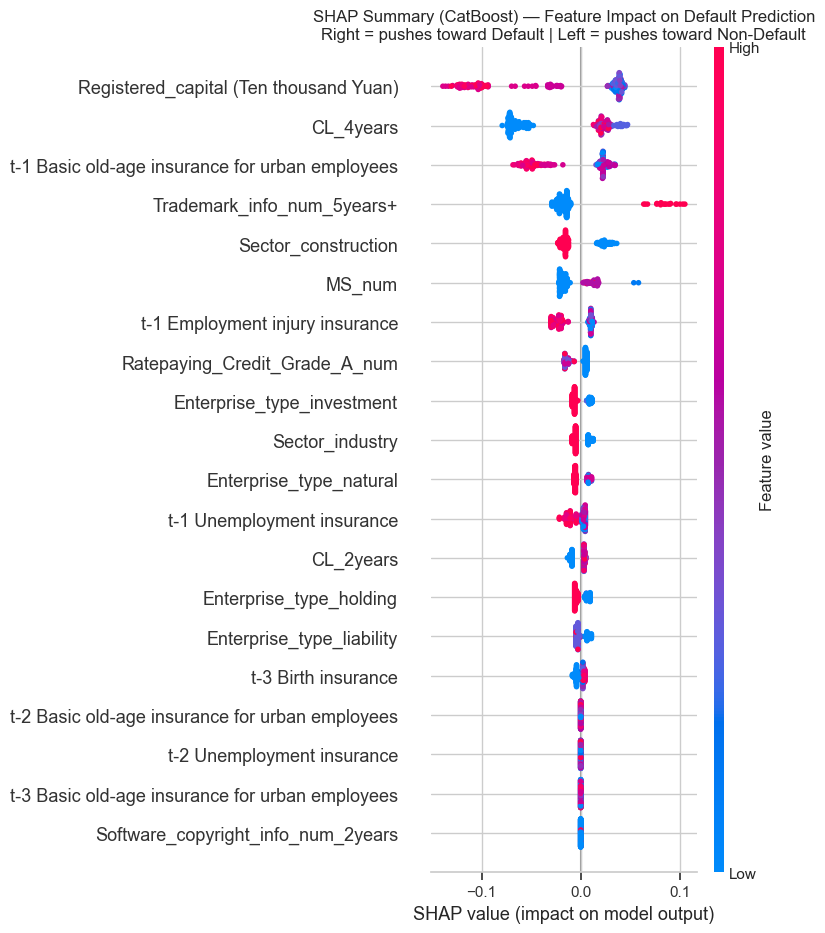

In [16]:
# Plot 1: SHAP Summary — Beeswarm
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test, show=False, max_display=20)
plt.title(f'SHAP Summary ({best_name}) — Feature Impact on Default Prediction\n'
          'Right = pushes toward Default | Left = pushes toward Non-Default', fontsize=12)
plt.tight_layout()
plt.show()

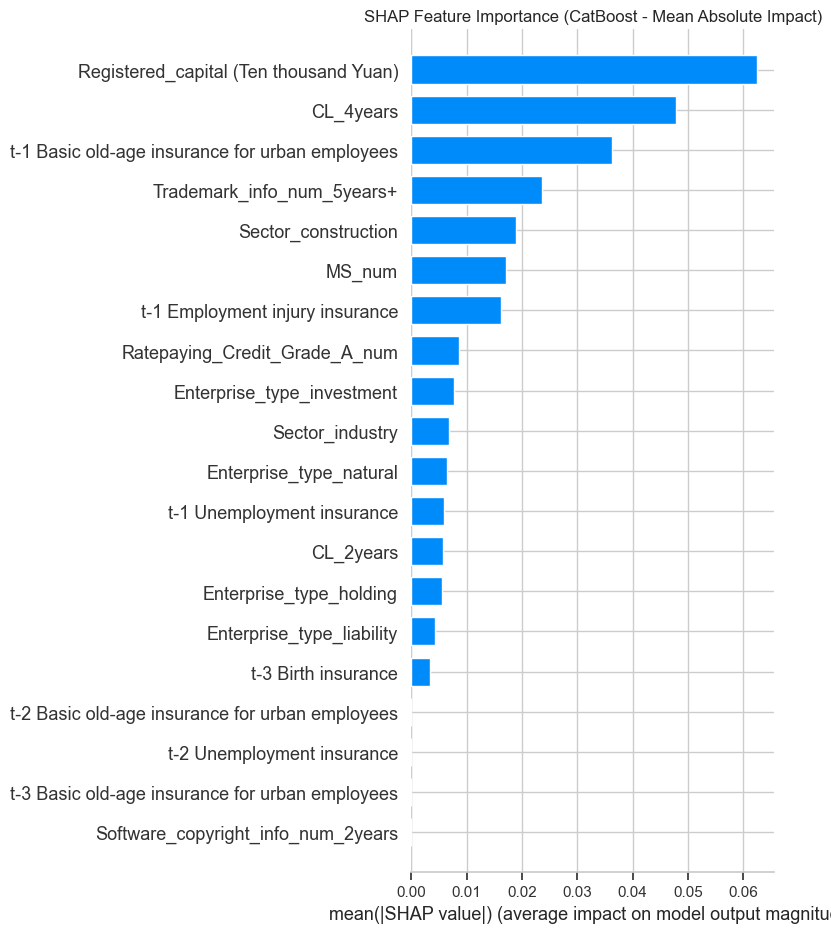

In [17]:
# Plot 2: SHAP Bar — Mean absolute importance
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test, plot_type='bar', show=False, max_display=20)
plt.title(f'SHAP Feature Importance ({best_name} - Mean Absolute Impact)', fontsize=12)
plt.tight_layout()
plt.show()


Explaining Company at position 32
Actual label: DEFAULT (1)
Model predicted default probability: 48.6%


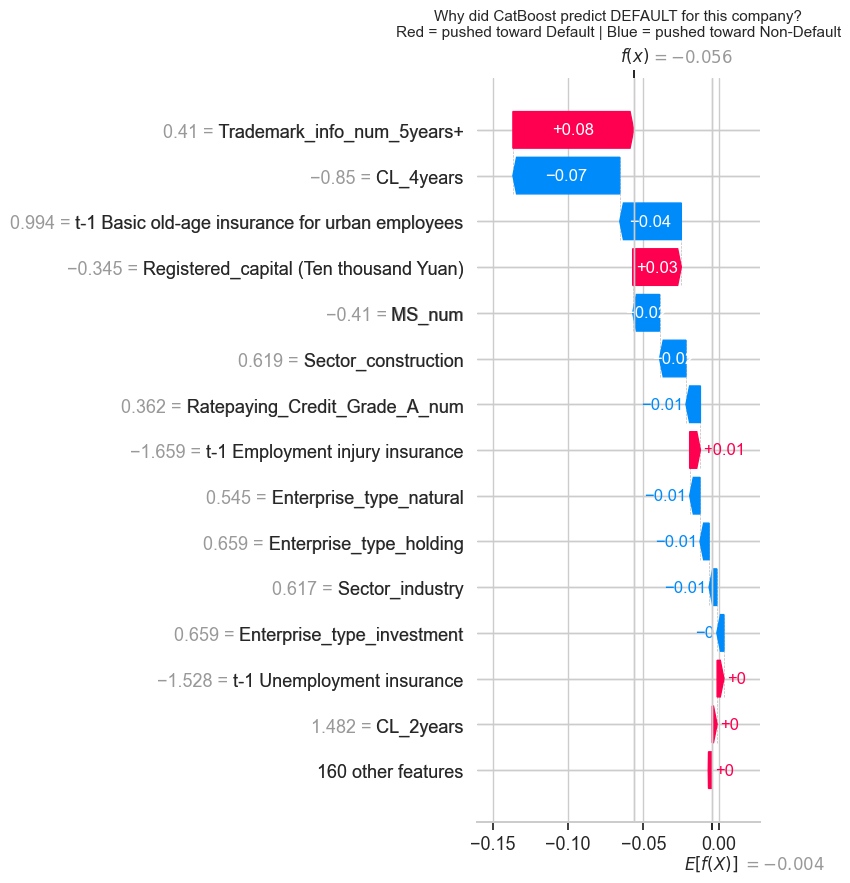

In [18]:
# Plot 3: SHAP Waterfall — explain ONE specific defaulted company
default_positions = [i for i, v in enumerate(y_test.values) if v == 1]

if default_positions:
    pos = default_positions[0]
    prob = best_probs[pos]

    print(f'\nExplaining Company at position {pos}')
    print(f'Actual label: DEFAULT (1)')
    print(f'Model predicted default probability: {prob:.1%}')

    # Extract single expected value (handles differences between XGB/CatBoost outputs)
    exp_value = explainer.expected_value[0] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value
    
    shap_exp = shap.Explanation(
        values=shap_values[pos],
        base_values=exp_value,
        data=X_test.iloc[pos].values,
        feature_names=X_test.columns.tolist()
    )
    plt.figure(figsize=(12, 6))
    shap.waterfall_plot(shap_exp, show=False, max_display=15)
    plt.title(f'Why did {best_name} predict DEFAULT for this company?\n'
              f'Red = pushed toward Default | Blue = pushed toward Non-Default', fontsize=11)
    plt.tight_layout()
    plt.show()
else:
    print('No default companies in test set found for waterfall plot.')


Most important feature by SHAP: Registered_capital (Ten thousand Yuan)


<Figure size 1000x600 with 0 Axes>

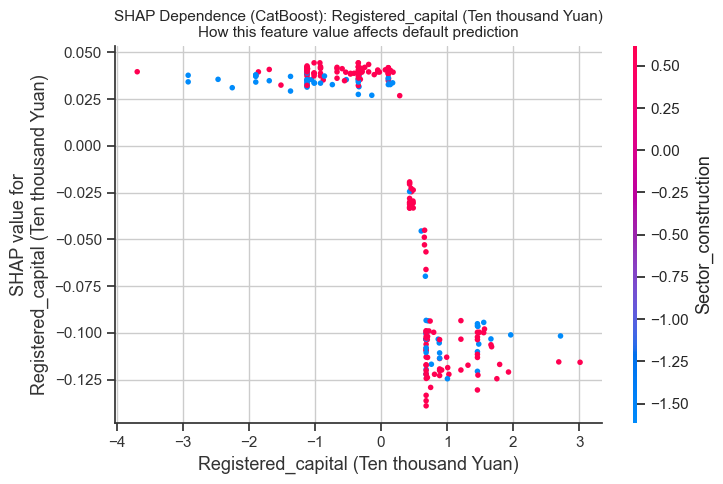

In [19]:
# Plot 4: SHAP Dependence Plot — most important feature
top_feat_idx  = np.abs(shap_values).mean(axis=0).argmax()
top_feat_name = X_test.columns[top_feat_idx]
print(f'\nMost important feature by SHAP: {top_feat_name}')

plt.figure(figsize=(10, 6))
shap.dependence_plot(
    top_feat_idx, shap_values, X_test,
    feature_names=X_test.columns.tolist(), show=False
)
plt.title(f'SHAP Dependence ({best_name}): {top_feat_name}\nHow this feature value affects default prediction',
          fontsize=11)
plt.tight_layout()
plt.show()